<a href="https://colab.research.google.com/github/Aiden-Ross-Dsouza/Natural-Language-Processing/blob/main/Text%20Generation/notebooks/Text_Generation_using_Decoder_Only_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import requests
import matplotlib.pyplot as plt

# Hyperparameters

In [20]:
batch_size = 64 # how many independent sequences will we process in parallel?
block_size = 256 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2

torch.manual_seed(1337)

# Dataset

In [3]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

response = requests.get(url)
if response.status_code == 200:
    with open('input.txt', 'w', encoding='utf-8') as f:
        f.write(response.text)
else:
    print(f"Failed to download file. Status code: {response.status_code}")

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
print(len(text))

1115394


In [5]:
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



# Vocabulary

In [6]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Train Val Test Split

In [7]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.8*len(data))
m = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:m]
test_data = data[m:]

# Data Loader

In [8]:
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

# Loss

In [9]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# Model

In [10]:
class Head(nn.Module):

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size (batch, time-step, head size)
        B,T,C = x.shape
        k = self.key(x)   # (B,T,hs)
        q = self.query(x) # (B,T,hs)
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 # (B, T, hs) @ (B, hs, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        v = self.value(x) # (B,T,hs)
        out = wei @ v # (B, T, T) @ (B, T, hs) -> (B, T, hs)
        return out

In [11]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

In [12]:
class FeedFoward(nn.Module):

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [13]:
class Block(nn.Module):

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [14]:
class GPTLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :] # becomes (B, C)
            probs = F.softmax(logits, dim=-1) # (B, C)
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

# Training

In [27]:
def train(model, device, max_iters, eval_interval, learning_rate, estimate_loss, get_batch):
    model = model.to(device)

    print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f} M parameters")

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    # Training loop
    for iter in range(max_iters):
        total_train_loss = 0
        total_eval_loss = 0

        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss()
            print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

        # Get a batch of data
        xb, yb = get_batch('train')

        # Forward pass: compute logits and loss
        logits, loss = model(xb, yb)

        # Zero the gradients, backpropagate the loss, and update the model parameters
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return train_losses, val_losses

model = GPTLanguageModel()
train_losses, val_losses = train(model, device, max_iters, eval_interval, learning_rate, estimate_loss, get_batch)

10.79 M parameters
step 0: train loss 4.1010, val loss 4.1006
step 500: train loss 1.7483, val loss 1.8637
step 1000: train loss 1.3925, val loss 1.5791
step 1500: train loss 1.2564, val loss 1.4831
step 2000: train loss 1.1751, val loss 1.4591
step 2500: train loss 1.1075, val loss 1.4511
step 3000: train loss 1.0424, val loss 1.4550
step 3500: train loss 0.9750, val loss 1.4788
step 4000: train loss 0.9138, val loss 1.5020
step 4500: train loss 0.8505, val loss 1.5241
step 4999: train loss 0.7912, val loss 1.5586


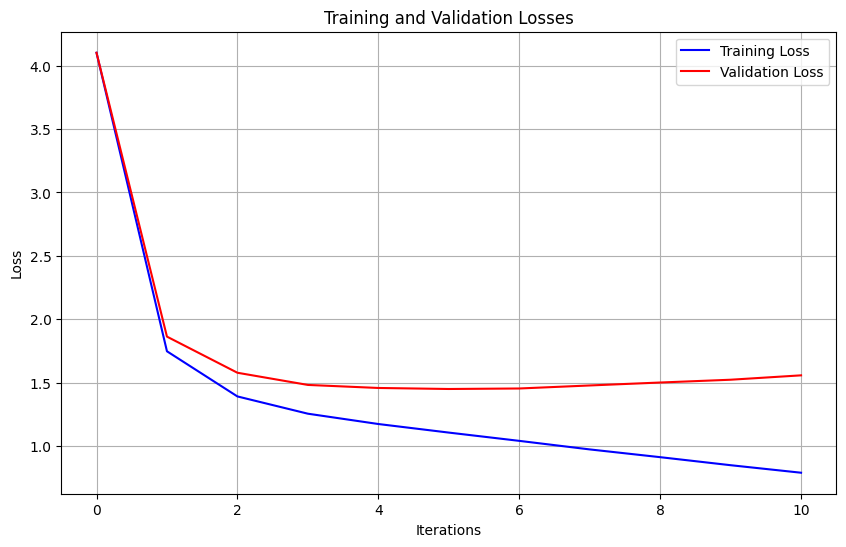

In [28]:
def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(train_losses)), train_losses, label="Training Loss", color="blue")
    plt.plot(range(len(val_losses)), val_losses, label="Validation Loss", color="red")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_losses(train_losses, val_losses)

# Generate Text

In [29]:
def generate_text(model, max_new_tokens, device, decode):
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    generated_tokens = model.generate(context, max_new_tokens=max_new_tokens)
    generated_text = decode(generated_tokens[0].tolist())
    return generated_text

max_new_tokens = 500
generated_text = generate_text(model, max_new_tokens, device, decode)
print(generated_text)


Hail short them as those penetent did
That lives for such swords at liars once
As 'twixt revail maintains and weary himself.
But is that Edward's sons thine coices,
Win standing that ne'er wear judge
Than scorn corns with peace. A Particus,
A causand dam light his; and in his
He migh die for the death and complots:
Let him share and danger with makes
Her chains a proper to her dear; the
hands your worthier heart, as he said at not
Comes quit him accuse, and we met him be of in sufferZet?

GLORDS
